In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib 

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd 
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image

In [7]:
import zipfile

zip_path = "(Dog & Cat ).zip"
extract_path = "dataset/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [8]:
def count_images(folder_path):
    total = 0
    for root, dirs, files in os.walk(folder_path):
        total += len(files)
    return total

train_count = count_images("dataset/train")
test_count = count_images("dataset/test")

print("Train Images:", train_count)
print("Test Images:", test_count)

Train Images: 20000
Test Images: 5000


In [9]:
train_path = "dataset/train"
test_path = "dataset/test"

In [10]:
# Data Augmentation (important for accuracy)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    validation_split=0.2   # 80% train, 20% validation
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
# Train Data
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)


Found 16000 images belonging to 2 classes.


In [12]:
# Validation Data
val_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

# Test Data
test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 4000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [13]:
model = models.Sequential()

#convolution Layer 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D(2,2))

#convolution Layer 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

#convolution Layer 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Flatten
model.add(layers.Flatten())

# Dense Layers
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

# Output Layer
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 720s 1s/step - accuracy: 0.5955 - loss: 0.6650 - val_accuracy: 0.6867 - val_loss: 0.6270
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 493s 986ms/step - accuracy: 0.6873 - loss: 0.5945 - val_accuracy: 0.7072 - val_loss: 0.5681
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 490s 979ms/step - accuracy: 0.7330 - loss: 0.5352 - val_accuracy: 0.7380 - val_loss: 0.5200
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 495s 989ms/step - accuracy: 0.7673 - loss: 0.4839 - val_accuracy: 0.7803 - val_loss: 0.4655
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 499s 997ms/step - accuracy: 0.7872 - loss: 0.4543 - val_accuracy: 0.7977 - val_loss: 0.4366
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 588s 1s/step - accuracy: 0.8052 - loss: 0.4304 - val_accuracy: 0.8175 - val_loss: 0.4021
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 508s 1s/step - accuracy: 0.8182 - loss: 0.4089 - val_accuracy: 0.7952 - val_loss: 0.4415
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 509s 1s/step - accuracy: 0.8229 - loss: 0.390

In [22]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 259ms/step - accuracy: 0.8776 - loss: 0.2879
Test Accuracy: 0.8776000142097473


In [24]:
import os

path = "dataset/test/cats"

if os.path.exists(path):
    print("Path exists")
    print(os.listdir(path)[:10])
else:
    print("Path NOT found")

print(os.listdir("dataset/test/cats")[:5])    

Path exists
['cat.10.jpg', 'cat.10000.jpg', 'cat.10001.jpg', 'cat.10007.jpg', 'cat.10017.jpg', 'cat.10021.jpg', 'cat.10026.jpg', 'cat.10030.jpg', 'cat.10033.jpg', 'cat.10035.jpg']
['cat.10.jpg', 'cat.10000.jpg', 'cat.10001.jpg', 'cat.10007.jpg', 'cat.10017.jpg']


In [89]:
# prediction
import random
folder = "dataset/test/cats"
file = random.choice(os.listdir(folder))

img_path = os.path.join(folder, file)
print("Using image:", img_path)

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    result = ("Dog")
else:
    result = ("Cat")
print("Prediction:", result)    

Using image: dataset/test/cats\cat.4097.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Prediction: Cat


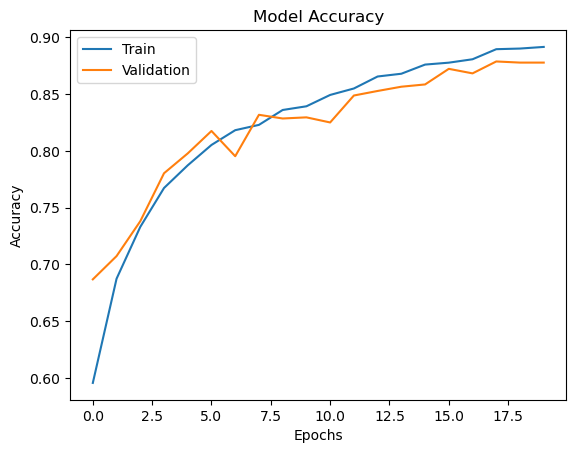

In [90]:
# accuracy
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

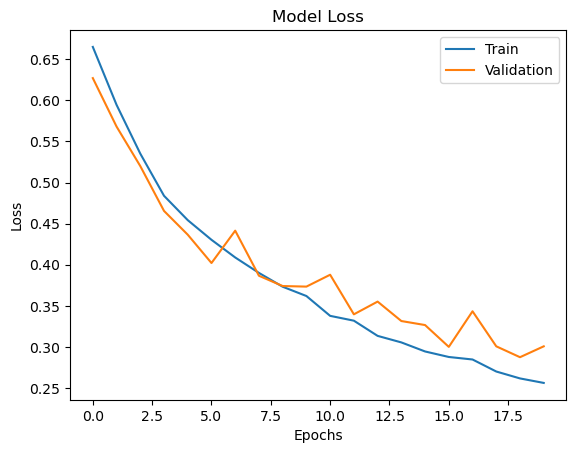

In [91]:
#loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

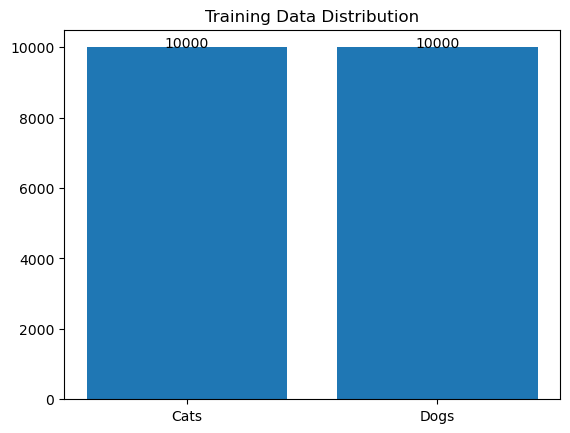

In [92]:
cats = len(os.listdir("dataset/train/cats"))
dogs = len(os.listdir("dataset/train/dogs"))

labels = ['Cats', 'Dogs']
values = [cats, dogs]

plt.bar(labels,values)
plt.text(0,cats + 5,str(cats),ha = 'center')
plt.text(1,dogs + 5,str(dogs),ha = 'center')
plt.title("Training Data Distribution")
plt.show()

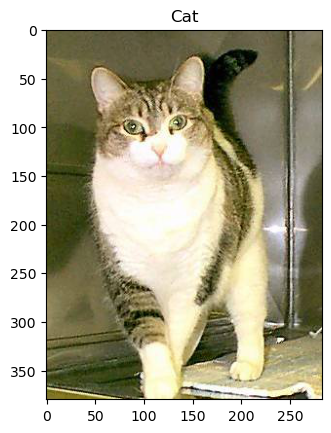

In [93]:
import matplotlib.pyplot as plt

img = image.load_img(img_path)
plt.imshow(img)
plt.title(result)
plt.show()

In [114]:
import random
folder = "dataset/test/dogs"
file = random.choice(os.listdir(folder))

img_path = os.path.join(folder, file)
print("Using image:", img_path)

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    result = ("Dog")
else:
    result = ("Cat")
print("Prediction:", result)

Using image: dataset/test/dogs\dog.11572.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Prediction: Dog


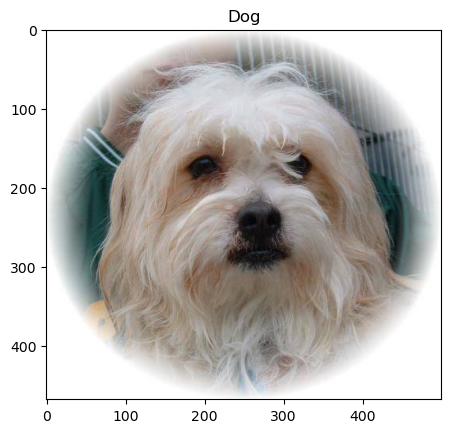

In [115]:
import matplotlib.pyplot as plt

img = image.load_img(img_path)
plt.imshow(img)
plt.title(result)
plt.show()